# Singapore vs. USA — enhanced-stack artifact comparison

Both artifacts were built from `auto_vnv_experiment` (post-merge with `abie_enhanced_consistent_rates`), so they share the 3-state dementia schema (mild / moderate / severe) + MCI + BBBM. Compare the headline rates from `cause.alzheimers_consistent.*` side-by-side.

Built under [[project-env-drift-2026-05]] workaround (db_queries downgraded to 31.2.2).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from vivarium import Artifact

from vivarium_csu_alzheimers.constants import data_keys

In [2]:
art_sgp = Artifact(path='singapore.hdf')
art_usa = Artifact(path='united_states_of_america.hdf')

In [3]:
def summarise(art, key):
    """Load `key` from `art` and collapse draws to mean / 2.5% / 97.5%."""
    data = art.load(key)
    data = (
        data.apply(pd.DataFrame.describe, percentiles=[0.025, 0.975], axis=1)
        .filter(['mean', '2.5%', '97.5%']).reset_index()
    )
    return data[data.age_end <= 95]


def compare_by_sex(key, label=None, ax=None):
    """Two-panel (Male / Female) plot of `key` for Singapore vs USA."""
    if ax is None:
        fig, ax = plt.subplots(ncols=2, sharex=True, sharey=True, figsize=(10, 4))
    label = label or key.split('.')[-1]
    sgp = summarise(art_sgp, key)
    usa = summarise(art_usa, key)
    for j, sex in enumerate(['Male', 'Female']):
        for i, (loc_name, src) in enumerate([('Singapore', sgp), ('USA', usa)]):
            color = f'C{i}'
            row = src.loc[src.sex == sex]
            ax[j].fill_between(row.age_start, row['2.5%'], row['97.5%'], alpha=0.2, color=color)
            ax[j].plot(row.age_start, row['mean'], color=color, linewidth=2, label=loc_name)
        ax[j].set_xlabel('Age (years)')
        ax[j].text(0.5, 0.95, sex, va='top', ha='center', transform=ax[j].transAxes)
        if j == 0:
            ax[j].set_ylabel(label)
        if j == 1:
            ax[j].legend(loc=(1.02, 0))
    plt.subplots_adjust(wspace=0)
    return ax

## Overall AD prevalence

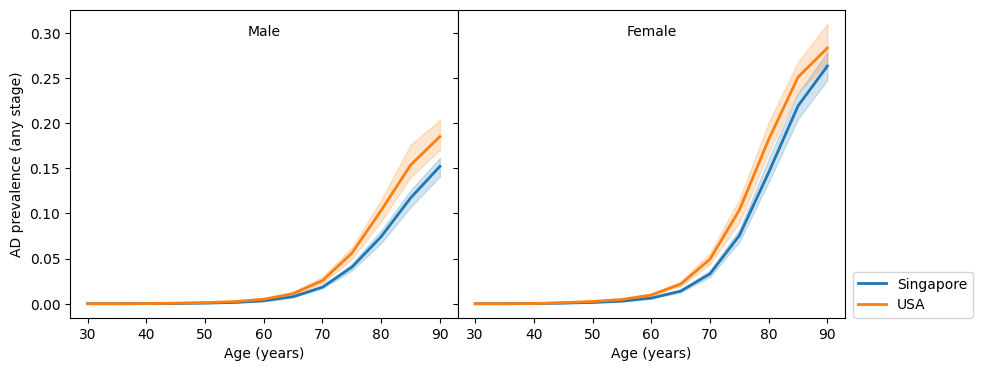

In [4]:
compare_by_sex(data_keys.ALZHEIMERS_CONSISTENT.AD_PREVALENCE, 'AD prevalence (any stage)');

## Conditional prevalence by stage

Conditional on AD (the five `delta_*` values sum to 1 by construction).

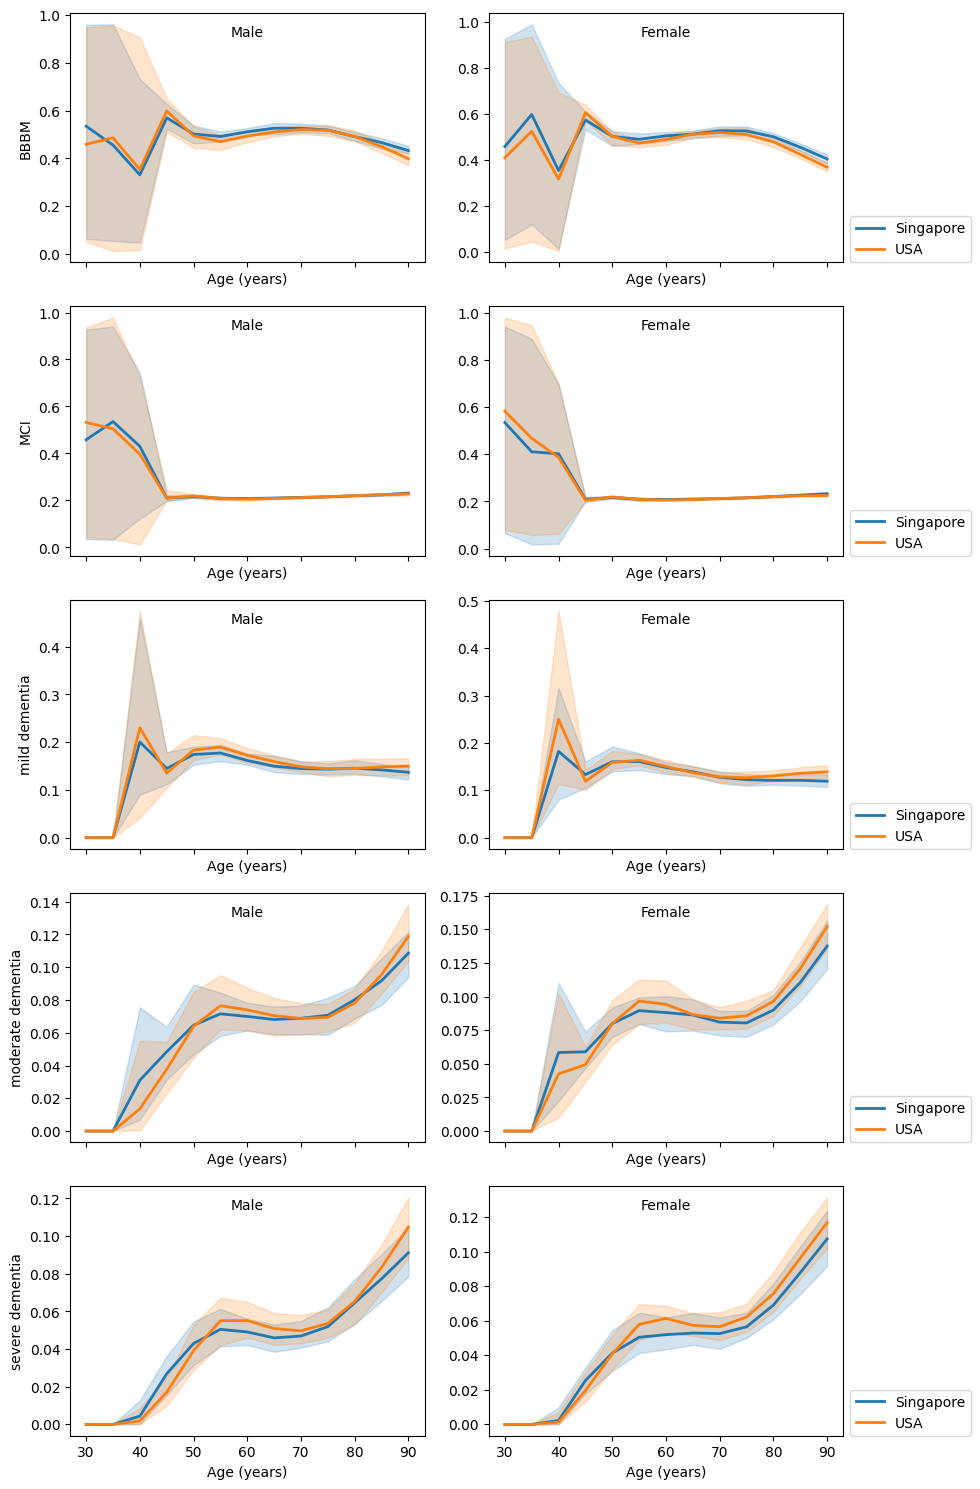

In [5]:
stage_keys = [
    (data_keys.ALZHEIMERS_CONSISTENT.BBBM_CONDITIONAL_PREVALENCE, 'BBBM'),
    (data_keys.ALZHEIMERS_CONSISTENT.MCI_CONDITIONAL_PREVALENCE, 'MCI'),
    (data_keys.ALZHEIMERS_CONSISTENT.MILD_DEMENTIA_CONDITIONAL_PREVALENCE, 'mild dementia'),
    (data_keys.ALZHEIMERS_CONSISTENT.MODERATE_DEMENTIA_CONDITIONAL_PREVALENCE, 'moderate dementia'),
    (data_keys.ALZHEIMERS_CONSISTENT.SEVERE_DEMENTIA_CONDITIONAL_PREVALENCE, 'severe dementia'),
]
fig, axes = plt.subplots(nrows=len(stage_keys), ncols=2, sharex=True, figsize=(10, 3 * len(stage_keys)))
for (key, label), row in zip(stage_keys, axes):
    compare_by_sex(key, label, ax=row)
fig.tight_layout()

## Stage-to-stage transition rates

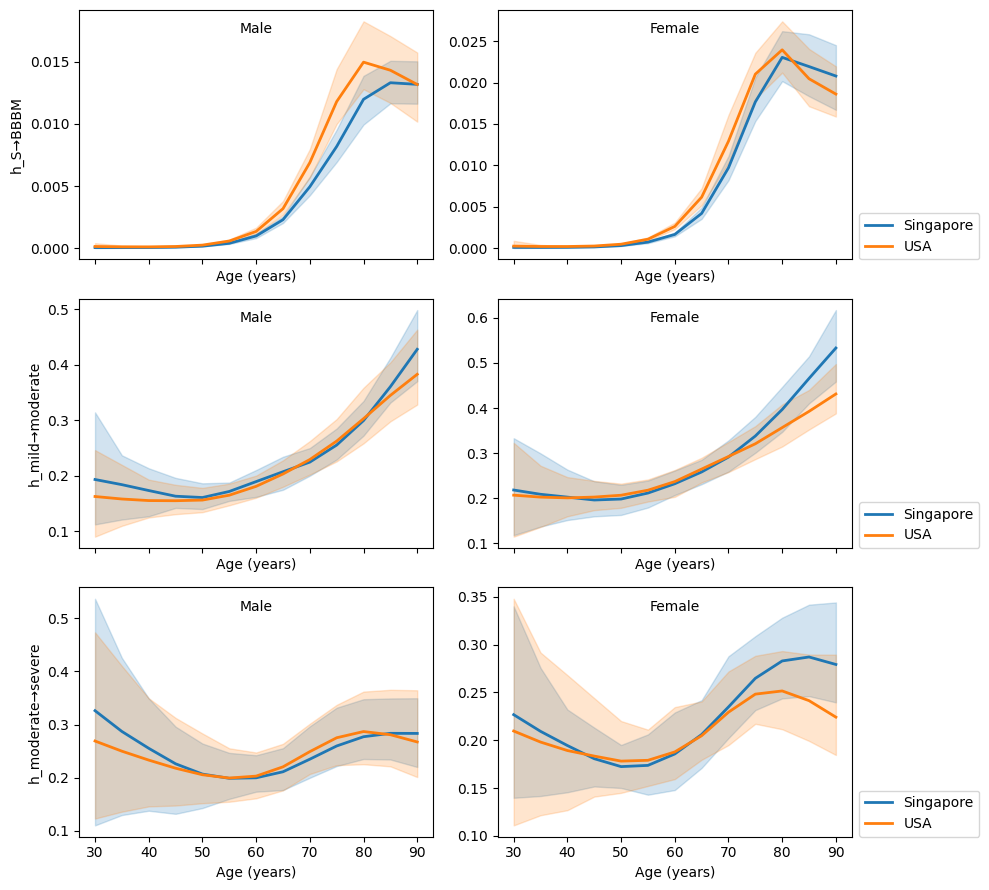

In [6]:
trans_keys = [
    (data_keys.ALZHEIMERS_CONSISTENT.BBBM_AD_INCIDENCE_RATE, 'h_S→BBBM'),
    (data_keys.ALZHEIMERS_CONSISTENT.MILD_TO_MODERATE_DEMENTIA_TRANSITION_RATE, 'h_mild→moderate'),
    (data_keys.ALZHEIMERS_CONSISTENT.MODERATE_TO_SEVERE_DEMENTIA_TRANSITION_RATE, 'h_moderate→severe'),
]
fig, axes = plt.subplots(nrows=len(trans_keys), ncols=2, sharex=True, figsize=(10, 3 * len(trans_keys)))
for (key, label), row in zip(trans_keys, axes):
    compare_by_sex(key, label, ax=row)
fig.tight_layout()

## Excess mortality by stage

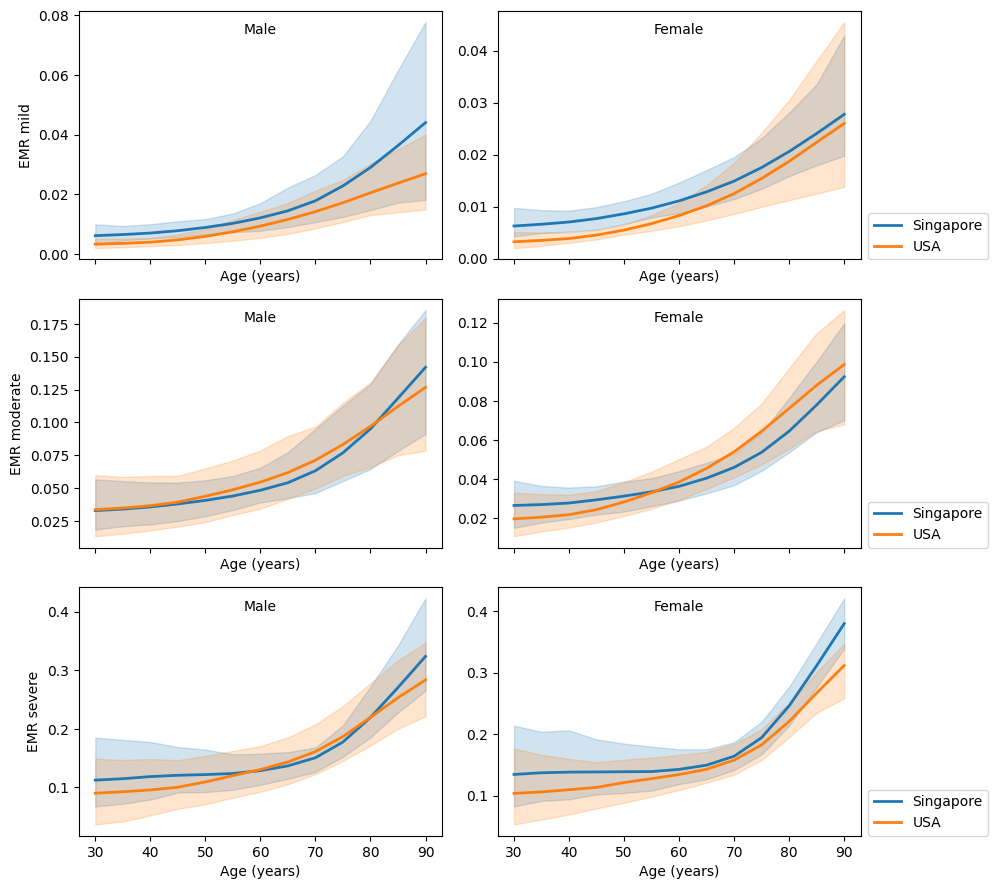

In [7]:
emr_keys = [
    (data_keys.ALZHEIMERS_CONSISTENT.EMR_MILD, 'EMR mild'),
    (data_keys.ALZHEIMERS_CONSISTENT.EMR_MODERATE, 'EMR moderate'),
    (data_keys.ALZHEIMERS_CONSISTENT.EMR_SEVERE, 'EMR severe'),
]
fig, axes = plt.subplots(nrows=len(emr_keys), ncols=2, sharex=True, figsize=(10, 3 * len(emr_keys)))
for (key, label), row in zip(emr_keys, axes):
    compare_by_sex(key, label, ax=row)
fig.tight_layout()

## CSMR and population incidence into mild dementia

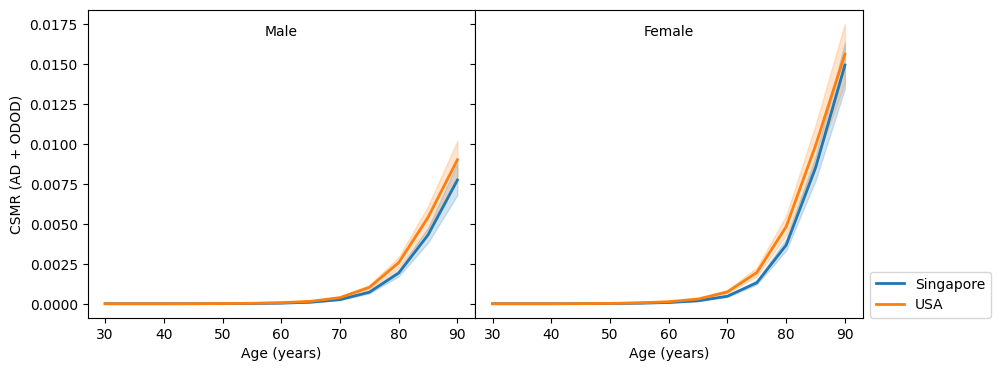

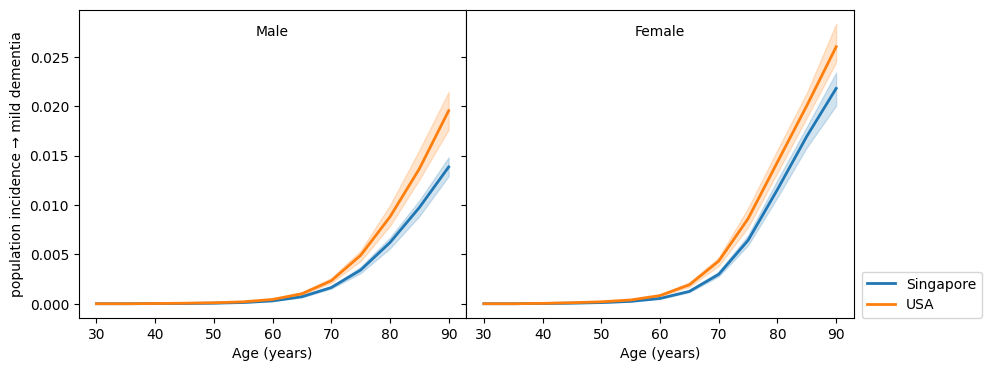

In [8]:
compare_by_sex(data_keys.ALZHEIMERS_CONSISTENT.CSMR, 'CSMR (AD + ODOD)');
compare_by_sex(data_keys.ALZHEIMERS_CONSISTENT.MILD_DEMENTIA_INCIDENCE_RATE_TOTAL_POPULATION, 'population incidence → mild dementia');

## ODE-consistency residuals (debug)

The MCMC penalises non-zero residuals; a small spread here is a sign the fit converged. Large values indicate the consistency constraint is fighting the data.

In [9]:
for art_name, art in [('Singapore', art_sgp), ('USA', art_usa)]:
    errs = art.load('cause.alzheimers_consistent.ode_errors')
    print(f'{art_name}: shape={errs.shape}  mean={errs.values.mean():.4f}  max={errs.values.max():.4f}')

Singapore: shape=(30, 500)  mean=0.0487  max=0.1072
USA: shape=(30, 500)  mean=0.0489  max=0.1053
